In [1]:
import json
import glob
from pathlib import Path, WindowsPath

import pandas as pd
import numpy as np

import re
import pyboat

In [2]:
pattern = r'mask_tf(\d+)_apoc_cell(\d+)\.json'
df = pd.DataFrame()

In [3]:
# Ordering functions

def ordering_function_tf(path):
    """Give the timeframe contained in the name of the json file as an integer.
    Use to sort metadata files"""
    
    pattern = r'mask_tf(\d+)_apoc_cell(\d+)\.json'
    match = re.match(pattern, path.name)
    return int(match.group(1))

def ordering_function_cell(path):
    """Give the cell number contained in the name of the json file as an integer.
    Use to sort metadata files"""

    pattern = r'mask_tf(\d+)_apoc_cell(\d+)\.json'
    match = re.match(pattern, path.name)
    return int(match.group(2))

In [4]:
def process_subdirectory(subdirectory_path, pattern=pattern, df=df):
    json_files = list(subdirectory_path.glob('mask_tf*_apoc_cell*.json'))
    json_files.sort(key=lambda x: (ordering_function_cell(x), ordering_function_tf(x)))
    cells = {re.match(pattern, file.name).group(2) for file in json_files} # Cell numbers as in the metadata file names

    # Check whether cells is emptyy or metadata has been found, if so populate df with average intenstiy
    if cells:
        for cell in cells:
            print(f'Recording cells {subdirectory.name}+{cell}')
            json_cell = [json_file for json_file in json_files if 'apoc_cell'+cell in json_file.stem]
            tfs = [int((re.match(pattern,json_file.name)).group(1)) for json_file in json_cell]
            tfs.sort()
            for (tf, json_file) in zip(tfs, json_cell):
                with json_file.open('r') as file:
                    data_dict = json.load(file)
                    npixels = data_dict.get('npixels')
                    intensity = data_dict.get('intensity')[1] if 'intensity' in data_dict and len(data_dict['intensity']) > 1 else None
                    column_name = subdirectory_path.name+'_'+cell
                    df.at[tf, column_name] = intensity/npixels
    else:
        print(f'No cell metadata in {subdirectory_path.name}')
    
    return df
    
    # except AttributeError as e:
    #     print(f'No cell metadata in {subdirectory_path.name}: {e}')
    #     pass

In [5]:
root_folder = Path("H:/PROJECTS-03/Pablo/oscillating/ppf024_analysis_median_corr/raw/metadata/ppf025")
subdirectories = list(root_folder.glob('*/'))[:-1]

In [6]:
df = pd.DataFrame()
for subdirectory in subdirectories:
    process_subdirectory(subdirectory, df=df)

Recording cells ppf024_xy01+0
Recording cells ppf024_xy02+0
Recording cells ppf024_xy02+2
Recording cells ppf024_xy02+1
Recording cells ppf024_xy03+0
Recording cells ppf024_xy04+0
Recording cells ppf024_xy05+0
Recording cells ppf024_xy06+0
Recording cells ppf024_xy06+1
Recording cells ppf024_xy07+0
Recording cells ppf024_xy08+0
Recording cells ppf024_xy08+1
Recording cells ppf024_xy09+0
Recording cells ppf024_xy10+0
Recording cells ppf024_xy11+0
Recording cells ppf024_xy12+0
Recording cells ppf024_xy13+0
Recording cells ppf024_xy14+0
Recording cells ppf024_xy15+0
Recording cells ppf024_xy16+0
Recording cells ppf024_xy17+0
Recording cells ppf024_xy18+0
Recording cells ppf024_xy19+0
Recording cells ppf024_xy20+0
Recording cells ppf024_xy21+0
Recording cells ppf024_xy22+0
Recording cells ppf024_xy22+1
Recording cells ppf024_xy23+0
Recording cells ppf024_xy23+1
Recording cells ppf024_xy24+0
Recording cells ppf024_xy25+0


KeyboardInterrupt: 

In [7]:
df = df.dropna(axis=1).reset_index().drop(axis=1,labels=['index'])

In [51]:
df

In [1]:
import json
import glob
from pathlib import Path, WindowsPath

import pandas as pd
import numpy as np

import re
import pyboat

# User arguments

pattern = r'mask_tf(\d+)_apoc_cell(\d+)\.json'
port = 5005
input_path = "H:/PROJECTS-03/Pablo/oscillating/ppf025_analysis_median_corr/raw/metadata/ppf025"
nan_threshold = 0.8
current_socket = 'localhost:8888'
df = pd.DataFrame()

# Ordering functions

def ordering_function_tf(path):
    """Give the timeframe contained in the name of the json file as an integer.
    Use to sort metadata files"""
    
    pattern = r'mask_tf(\d+)_apoc_cell(\d+)\.json'
    match = re.match(pattern, path.name)
    return int(match.group(1))

def ordering_function_cell(path):
    """Give the cell number contained in the name of the json file as an integer.
    Use to sort metadata files"""

    pattern = r'mask_tf(\d+)_apoc_cell(\d+)\.json'
    match = re.match(pattern, path.name)
    return int(match.group(2))

def process_subdirectory(subdirectory_path, pattern=pattern, df=df):
    json_files = list(subdirectory_path.glob('mask_tf*_apoc_cell*.json'))
    json_files.sort(key=lambda x: (ordering_function_cell(x), ordering_function_tf(x)))
    cells = {re.match(pattern, file.name).group(2) for file in json_files} # Cell numbers as in the metadata file names

    # Check whether cells is emptyy or metadata has been found, if so populate df with average intenstiy
    if cells:
        for cell in cells:
            print(f'Recording cells {subdirectory.name}+{cell}')
            json_cell = [json_file for json_file in json_files if 'apoc_cell'+cell in json_file.stem]
            tfs = [int((re.match(pattern,json_file.name)).group(1)) for json_file in json_cell]
            tfs.sort()
            for (tf, json_file) in zip(tfs, json_cell):
                with json_file.open('r') as file:
                    data_dict = json.load(file)
                    npixels = data_dict.get('npixels')
                    intensity = data_dict.get('intensity')[1] if 'intensity' in data_dict and len(data_dict['intensity']) > 1 else None
                    column_name = subdirectory_path.name+'_'+cell
                    df.at[tf, column_name] = intensity/npixels
    else:
        print(f'No cell metadata in {subdirectory_path.name}')
    
    return df
    
    # except AttributeError as e:
    #     print(f'No cell metadata in {subdirectory_path.name}: {e}')
    #     pass

root_folder = Path(input_path)
subdirectories = list(root_folder.glob('*/'))[:-1]

for subdirectory in subdirectories:
    process_subdirectory(subdirectory, df=df)

# Filter traces with nan_values defined by nan_threshold

df_cleaned = df.drop(columns=df.columns[df.isna().sum() > nan_threshold*len(df)])

from bokeh.io import output_notebook, show, push_notebook
from bokeh.layouts import column, row
from bokeh.models import Button, ColumnDataSource, CustomJS
from bokeh.plotting import figure, curdoc
from bokeh.application.handlers import FunctionHandler
from bokeh.application import Application
from bokeh.server.server import Server
from tornado.ioloop import IOLoop
import asyncio


global valid_signals

def modify_doc(doc):
    # Initialize selected_plots as a ColumnDataSource
    selected_plots_source = ColumnDataSource(data=dict(selected_plots=[]))

    # Function to get selected plots in Python
    def get_selected_plots():
        return selected_plots_source.data['selected_plots']

    # Function to create plots and buttons layout
    def create_plots_layout():
        plots = []
        buttons = []

        for col in df_cleaned.columns:
            if col not in get_selected_plots():
                source = ColumnDataSource(data={col: df_cleaned[col], 'x': range(len(df_cleaned))})
                p = figure(width=250, height=250, title=col)
                r = p.line('x', col, source=source, line_width=2, color='navy', alpha=0.8)

                button = Button(label=col, width=60, button_type="success")

                def create_button_callback(plot, column_name, btn):
                    def callback():
                        selected_plots = selected_plots_source.data['selected_plots']
                        if column_name in selected_plots:
                            plot.background_fill_color = 'white'
                            selected_plots.remove(column_name)
                            btn.button_type = 'success'
                        else:
                            plot.background_fill_color = 'rgba(255, 0, 0, 0.1)'
                            selected_plots.append(column_name)
                            btn.button_type = 'danger'
                        selected_plots_source.data = {'selected_plots': selected_plots}  # Update the data source
                        global valid_signals
                        valid_signals = df_cleaned.drop(columns=selected_plots_source.data['selected_plots']).columns
                        # push_notebook()  # Ensure updates are reflected in the notebook
                    return callback

                button.on_click(create_button_callback(p, col, button))

                plots.append(p)
                buttons.append(button)

        # Organize layout
        plot_rows = []
        for i in range(0, len(plots), 5):
            plot_row = plots[i:i+5]
            button_row = buttons[i:i+5]
            plot_rows.append(row(*plot_row, column(*button_row)))

        layout = column(*plot_rows)
        return layout

    # Create the initial layout
    layout = create_plots_layout()

    # Button to print excluded plots
    print_button = Button(label="Print list of excluded plots", width=200, button_type="primary")
    def print_selected_plots():
        print(get_selected_plots())
        # push_notebook()  # Ensure notebook updates
    print_button.on_click(print_selected_plots)

    # Button to rerender without selected plots
    rerender_button = Button(label="Exclude selected plots", width=200, button_type="warning")
    def rerender_plots():
        new_layout = create_plots_layout()
        doc.clear()  # Clear the current document
        doc.add_root(column(new_layout, print_button, rerender_button))
        # push_notebook()
    rerender_button.on_click(rerender_plots)

    # Add the layout and buttons to the current document
    doc.add_root(column(layout, print_button, rerender_button))

# Create the application
app = Application(FunctionHandler(modify_doc))


# Display app
# show(app, notebook_handle=True) - Carefull to push notebook

# Or do it through a server

#  Start the Bokeh server
# server = Server({'/': modify_doc}, port=4996)
#  server.start()

# def show_app():
#     server.io_loop.add_callback(server.show, "/")
#     server.io_loop.start()

# show_app()

#########################
# Integrate with the current Jupyter server -- To be checked
server = Server({'/': modify_doc}, port=port, io_loop=IOLoop.current(), allow_websocket_origin=[current_socket, "localhost:"+str(port)])

async def show_app():
    server.io_loop.add_callback(server.show, "/")
    await server.io_loop.start()

# Integrate with the Jupyter notebook event loop
loop = asyncio.get_event_loop()
if loop.is_running():
    loop.create_task(show_app())
else:
    loop.run_until_complete(show_app())

# Store valid signals

Recording cells ppf025_xy001+0
Recording cells ppf025_xy002+0
Recording cells ppf025_xy003+0
Recording cells ppf025_xy004+0
Recording cells ppf025_xy005+0
Recording cells ppf025_xy006+0
Recording cells ppf025_xy007+0
Recording cells ppf025_xy007+1
Recording cells ppf025_xy008+0
Recording cells ppf025_xy009+0
Recording cells ppf025_xy009+1
Recording cells ppf025_xy010+0
Recording cells ppf025_xy011+0
Recording cells ppf025_xy012+0
Recording cells ppf025_xy013+0
Recording cells ppf025_xy014+0
Recording cells ppf025_xy015+0
Recording cells ppf025_xy016+0
Recording cells ppf025_xy017+0
Recording cells ppf025_xy018+0
Recording cells ppf025_xy019+0
Recording cells ppf025_xy020+0
Recording cells ppf025_xy021+0
Recording cells ppf025_xy021+1
Recording cells ppf025_xy022+0
Recording cells ppf025_xy023+0
Recording cells ppf025_xy024+0
Recording cells ppf025_xy025+0
Recording cells ppf025_xy026+0
Recording cells ppf025_xy027+0
Recording cells ppf025_xy028+0
Recording cells ppf025_xy029+0
Recordin

C:\Users\pperez\AppData\Local\Temp\14\ipykernel_40516\3276022812.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.at[tf, column_name] = intensity/npixels


Recording cells ppf025_xy092+0


C:\Users\pperez\AppData\Local\Temp\14\ipykernel_40516\3276022812.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.at[tf, column_name] = intensity/npixels


Recording cells ppf025_xy092+1
Recording cells ppf025_xy093+0


...

C:\Users\pperez\AppData\Local\Temp\14\ipykernel_40516\3276022812.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.at[tf, column_name] = intensity/npixels
C:\Users\pperez\AppData\Local\Temp\14\ipykernel_40516\3276022812.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.at[tf, column_name] = intensity/npixels


Recording cells ppf025_xy099+0


C:\Users\pperez\AppData\Local\Temp\14\ipykernel_40516\3276022812.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.at[tf, column_name] = intensity/npixels


Recording cells ppf025_xy100+0
Recording cells ppf025_xy101+0


C:\Users\pperez\AppData\Local\Temp\14\ipykernel_40516\3276022812.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.at[tf, column_name] = intensity/npixels
C:\Users\pperez\AppData\Local\Temp\14\ipykernel_40516\3276022812.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.at[tf, column_name] = intensity/npixels
INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.4)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)
ERROR:asyncio:Task exception was never

In [12]:
df_cleaned[valid_signals].to_csv('./valid_signals_ppf021')

## HERE GOES AN ITERATIVE WAY TO DECIDE WHAT TO DO WITH NAN VALUES -- TO BE DONE ##

# STOP SERVER AND FREE PORT

In [2]:
server.io_loop.stop()

In [72]:
assign_position(df)    

Index(['ppf008_xy002_0', 'ppf008_xy003_1', 'ppf008_xy004_0', 'ppf008_xy005_0',
       'ppf008_xy006_0', 'ppf008_xy007_0', 'ppf008_xy007_1', 'ppf008_xy008_0',
       'ppf008_xy009_0', 'ppf008_xy010_0',
       ...
       'ppf008_xy158_0', 'ppf008_xy159_0', 'ppf008_xy160_0', 'ppf008_xy161_0',
       'ppf008_xy162_0', 'ppf008_xy163_0', 'ppf008_xy163_1', 'ppf008_xy164_0',
       'ppf008_xy165_0', 'ppf008_xy166_0'],
      dtype='object', length=172) [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80] time point
0     1.102293
1     1.166352
2     1.113118
3     1.157488
4     1.387104
        ...   
76    1.055350
77    1.041169
78    1.053891
79    1.048971
80    1.052684
Name: ppf008_xy003_1, Length: 81, dtype: float64
            ppf008_xy002_0  ppf008_xy003_1  ppf008_xy004_0  ppf008_xy005_0  \
t

In [1]:
import pandas as pd

In [2]:
df_interpolate = df_cleaned[valid_signals].interpolate(method='linear', axis=1)

In [2]:
df = pd.read_csv('./valid_signals_ppf021', index_col=0)

In [11]:
df = df.dropna(axis=1)

In [3]:
df_interpolate.to_csv('./valid_signals_ppf025_bs_median_interpol')

In [10]:
df.columns[df.isna().sum()>0.8*len(df)]

Index(['ppf020_xy003_1', 'ppf020_xy011_0', 'ppf020_xy024_1', 'ppf020_xy025_3',
       'ppf020_xy048_1', 'ppf020_xy084_2', 'ppf020_xy085_1', 'ppf020_xy086_1',
       'ppf020_xy087_1', 'ppf020_xy100_1', 'ppf020_xy100_2', 'ppf020_xy102_2',
       'ppf020_xy103_3', 'ppf020_xy103_2', 'ppf020_xy117_1', 'ppf020_xy117_2',
       'ppf020_xy120_1'],
      dtype='object')

In [11]:
df_cleaned = df.drop(columns=df.columns[df.isna().sum() > 0.8*len(df)])

,ppf024_xy01_0,ppf024_xy02_0,ppf024_xy02_1,ppf024_xy03_0,ppf024_xy04_0,ppf024_xy05_0,ppf024_xy06_0,ppf024_xy06_1,ppf024_xy07_0,ppf024_xy08_0,...,ppf024_xy91_0,ppf024_xy92_0,ppf024_xy93_1,ppf024_xy94_0,ppf024_xy95_0,ppf024_xy96_0,ppf024_xy96_1,ppf024_xy97_0,ppf024_xy98_0,ppf024_xy99_0
0,52.739130,24.824612,5.696471,113.477941,71.432081,56.082022,90.867299,9.995116,262.475524,7.052533,...,51.555710,33.308767,16.423381,33.555066,1.391304,75.488785,16.718702,172.840467,20.482808,17.810235
1,43.300872,16.163924,50.291672,84.419419,52.875661,40.270242,83.019157,7.383208,263.091603,12.726244,...,44.552137,37.783784,27.115385,49.095745,16.106129,83.372004,11.505747,103.058962,21.587261,10.183778
2,37.421751,13.805090,-3.339667,78.748140,69.891667,16.945078,56.688976,4.148112,171.150685,-1.966702,...,24.541502,28.331090,29.735549,38.305483,16.367989,87.838178,7.475928,43.922194,34.956806,19.600667
3,28.630363,12.976311,3.715596,88.443170,103.106650,14.201213,46.613718,5.917838,85.842875,11.993651,...,9.543385,18.512605,12.241015,36.848375,17.750308,69.642857,1.046917,29.679856,34.573138,28.374616
4,36.360481,22.839791,68.644498,114.449204,88.158377,15.811512,113.494340,4.812274,54.288136,3.611233,...,25.619048,19.606784,14.883991,36.895597,14.224234,103.727463,10.886885,25.628219,18.166018,26.848337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,71.444828,41.558805,11.672783,80.031953,49.613610,13.834731,56.341394,17.623815,58.443570,38.333943,...,18.911958,241.792844,12.618598,53.202703,10.240319,144.688657,12.457189,99.121160,28.879581,51.755862
71,71.833622,42.953927,14.074231,88.548652,64.094645,59.220127,54.345609,8.819018,58.823841,34.788851,...,28.399129,235.063080,21.098202,53.680899,18.671859,147.678984,16.658497,94.317032,26.302730,58.837725
72,75.709343,39.202189,2.695035,89.864009,64.894366,63.752293,62.610219,9.468560,60.407407,36.302760,...,24.746405,229.780000,12.762219,54.782609,16.284304,145.951724,11.033708,86.313312,22.833972,58.072122
73,71.947020,39.662084,7.377149,86.896919,63.128755,62.922037,62.715318,11.657996,56.347185,37.180026,...,19.484085,209.994681,15.428000,59.739773,13.574656,141.527273,8.858034,86.963516,35.350757,52.171388


In [2]:
import pandas as pd

In [4]:
df_cleaned=pd.read_csv('./valid_signals_ppf025_bs_median_interpol', index_col=0)

In [5]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot
from bokeh.models import ColumnDataSource, HoverTool

# Enable Bokeh output in the notebook
output_notebook()

# Number of plots per row
plots_per_row = 5

# Create a list to hold all the plots
plots = []

for col in df_cleaned.columns:
    # Create a ColumnDataSource for each column
    source = ColumnDataSource(data=dict(index=df_cleaned.index, values=df_cleaned[col]))

    # Create a new plot
    p = figure(title=col, plot_width=275, plot_height=275, tools="hover", tooltips="@index: @values")

    # Add a line renderer with legend and line thickness
    p.line('index', 'values', source=source, line_width=2)
    
    # Add the plot to the list of plots
    plots.append(p)

# Arrange the plots in a grid
grid = gridplot(plots, ncols=plots_per_row)

# Show the results in the notebook
show(grid)

Loading BokehJS ...

In [13]:
import pandas as pd
import numpy as np
from bokeh.io import output_notebook, show
from bokeh.layouts import gridplot, column
from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, TapTool
from bokeh.events import Tap
from bokeh.models.widgets import Div
from bokeh.server.server import Server
from bokeh.embed import server_document
from IPython.display import display, HTML

# Enable Bokeh output in the notebook
output_notebook()

# Number of plots per row
plots_per_row = 5

# Create a list to hold all the plots
plots = []
selected_columns = []

# Create a Div to display selected column names
div = Div(width=800, height=40)

# JavaScript code to handle tap events
tap_js_code = """
    var column_name = cb_obj.title.text;
    if (!selected_columns.includes(column_name)) {
        selected_columns.push(column_name);
        cb_obj.background_fill_color = "lightgreen";
    } else {
        var index = selected_columns.indexOf(column_name);
        selected_columns.splice(index, 1);
        cb_obj.background_fill_color = "white";
    }
    button_callback.args.selected_columns = selected_columns;
"""

# JavaScript code to handle button click
button_js_code = """
    div.text = "Selected columns: " + selected_columns.join(', ');
"""

# Create a Button to retrieve selected column names
button = Button(label="Get Selected Columns", button_type="success")

# CustomJS callback for the button
button_callback = CustomJS(args=dict(div=div, selected_columns=selected_columns), code=button_js_code)
button.js_on_click(button_callback)

for col in df_cleaned.columns:
    # Create a ColumnDataSource for each column
    source = ColumnDataSource(data=dict(index=df_cleaned.index, values=df_cleaned[col]))

    # Create a new plot
    p = figure(title=col, plot_width=250, plot_height=250, tools="hover,tap", tooltips="@index: @values")

    # Add a line renderer with legend and line thickness
    p.line('index', 'values', source=source, line_width=2)

    # Add TapTool to the plot with a CustomJS callback
    tap_callback = CustomJS(args=dict(selected_columns=selected_columns, button_callback=button_callback), code=tap_js_code)
    p.js_on_event(Tap, tap_callback)

    # Add the plot to the list of plots
    plots.append(p)

# Arrange the plots in a grid
grid = gridplot(plots, ncols=plots_per_row)

# Display the layout
notebook_url = 'localhost:8888'
# show(modify_doc, notebook_url=notebook_url)
server = Server({'/': modify_doc}, port=5010, num_procs=1,allow_websocket_origin=["localhost:8888"])
server.start()

script = server_document('http://localhost:5010/')
display(HTML(script))

Loading BokehJS ...

NameError: name 'modify_doc' is not defined

In [16]:
import pandas as pd
import numpy as np
from bokeh.io import output_notebook, show
from bokeh.layouts import gridplot, column
from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, TapTool
from bokeh.events import Tap
from bokeh.models.widgets import Div
from bokeh.server.server import Server
from bokeh.embed import server_document
from IPython.display import display, HTML

output_notebook()

# Create a sample DataFrame
np.random.seed(42)
df_cleaned = pd.DataFrame(np.random.rand(100, 10), columns=[f'col_{i}' for i in range(10)])

def modify_doc(doc):
    sources = {col: ColumnDataSource(data={'x': df_cleaned.index, 'y': df_cleaned[col]}) for col in df_cleaned.columns}

    plots = []
    plot_refs = {}
    for i, col in enumerate(df_cleaned.columns):
        p = figure(plot_width=200, plot_height=200, title=col, tools='tap', name=col)
        p.line('x', 'y', source=sources[col])
        plots.append(p)
        plot_refs[p] = col

    selected_columns = []

    def tap_callback(event):
        for p in plots:
            # Convert screen space event coordinates to figure coordinates
            x_range = p.x_range
            y_range = p.y_range
            x_start, x_end = p.frame.x_start, p.frame.x_end
            y_start, y_end = p.frame.y_start, p.frame.y_end
            
            if x_start <= event.sx <= x_end and y_start <= event.sy <= y_end:
                col = plot_refs[p]
                if col in selected_columns:
                    selected_columns.remove(col)
                    p.outline_line_color = None
                else:
                    selected_columns.append(col)
                    p.outline_line_color = "red"
                break

    for p in plots:
        p.on_event(Tap, tap_callback)

    grid = gridplot(plots, ncols=5)

    button = Button(label="Get Selected Columns")
    output_div = Div()

    def button_callback():
        output_div.text = "Selected columns: " + ", ".join(selected_columns)

    button.on_click(button_callback)

    layout = column(grid, button, output_div)
    doc.add_root(layout)

notebook_url = 'localhost:8888'
# show(modify_doc, notebook_url=notebook_url)
server = Server({'/': modify_doc}, port=5011, num_procs=1,allow_websocket_origin=["localhost:8888"])
server.start()

script = server_document('http://localhost:5011/')
display(HTML(script))

Loading BokehJS ...

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.4)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)


INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=40798&bokeh-absolute-url=http://localhost:5011 (::1) 249.00ms
INFO:tornado.access:200 GET /static/js/bokeh-gl.min.js?v=e5df31fd9010eacff0aa72d315264604b5e34972ba445acea6fce98080eecf33acf2d2986126360faaa5852813cffa16f6f6f4889923318300f062497c02da4e (::1) 212.05ms
INFO:tornado.access:200 GET /static/js/bokeh-widgets.min.js?v=8a1ff6f5aa0d967f4998d275803bbb111d928fd9f605ef9e1f30cfd021df0e77224ee3d13f83edb3a942f6e4ccc569ee5dd8951a8aa6cb600602463b90c65a87 (::1) 11.94ms
INFO:tornado.access:200 GET /static/js/bokeh-tables.min.js?v=ae2903e57cf57f52819fdf4d938c648982b51c34f73b6e653a0f3bb3c8ab44f338505931ace43eafc1636e215492e2314acf54c54baffb47813b86b4923a7fe0 (::1) 13.00ms
INFO:tornado.access:200 GET /static/js/bokeh.min.js?v=3c61e952b808bb7e346ce828a565a5f23aaf7708d034fa9d0906403813355d45bb4e8d8b0b23a93f032c76831d4f0221846f28699c7f5147caa62e0d31668314 (::1) 226.98ms
INFO:tornado.access:200 GET /static/js/bokeh-mathjax.min.js?v=176c

In [5]:
import pandas as pd
import numpy as np
from bokeh.io import output_notebook, show
from bokeh.layouts import gridplot, column
from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, TapTool, Div
from bokeh.events import Tap
from bokeh.server.server import Server
from bokeh.embed import server_document
from IPython.display import display, HTML

output_notebook()

# Sample DataFrame
np.random.seed(42)
df_cleaned = pd.DataFrame(np.random.rand(100, 10), columns=[f'col_{i}' for i in range(10)])

server = None

def start_bokeh_server():
    global server

    def modify_doc(doc):
        sources = {col: ColumnDataSource(data={'x': df_cleaned.index, 'y': df_cleaned[col]}) for col in df_cleaned.columns}
        plots = []
        plot_refs = {}
        plot_width = 200
        plot_height = 200

        for i, col in enumerate(df_cleaned.columns):
            p = figure(plot_width=plot_width, plot_height=plot_height, title=col, tools='tap', name=col)
            p.line('x', 'y', source=sources[col])
            plots.append(p)
            plot_refs[p] = col

        selected_columns = []
        print(plot_refs)

        def tap_callback(event):
            for p in plots:
                x_range = p.x_range
                y_range = p.y_range
                x_start, x_end = p.x_range.start, p.x_range.end
                y_start, y_end = p.y_range.start, p.y_range.end
                print(event.x, event.y)
                
                if x_start <= event.x <= x_end and y_start <= event.y <= y_end:
                    col = plot_refs[p]
                    if col in selected_columns:
                        selected_columns.remove(col)
                        p.outline_line_color = None
                    else:
                        selected_columns.append(col)
                        p.outline_line_color = "red"
                    break

        for p in plots:
            p.on_event(Tap, tap_callback)

        grid = gridplot(plots, ncols=5)

        button = Button(label="Get Selected Columns")
        output_div = Div()

        def button_callback():
            output_div.text = "Selected columns: " + ", ".join(selected_columns)

        button.on_click(button_callback)

        layout = column(grid, button, output_div)
        doc.add_root(layout)

    # Specify a different port number and allow websocket origin for Jupyter notebook
    server = Server({'/': modify_doc}, port=5003, num_procs=1, allow_websocket_origin=["localhost:8888"])
    server.start()

    script = server_document('http://localhost:5003/')
    display(HTML(script))

def stop_bokeh_server():
    global server
    if server is not None:
        server.stop()
        server.io_loop.stop()
        server = None

# Start the server
start_bokeh_server()

# To stop the server, call stop_bokeh_server()
# stop_bokeh_server()

Loading BokehJS ...

{Figure(id='4029', ...): 'col_0', Figure(id='4057', ...): 'col_1', Figure(id='4085', ...): 'col_2', Figure(id='4113', ...): 'col_3', Figure(id='4141', ...): 'col_4', Figure(id='4169', ...): 'col_5', Figure(id='4197', ...): 'col_6', Figure(id='4225', ...): 'col_7', Figure(id='4253', ...): 'col_8', Figure(id='4281', ...): 'col_9'}
66.05435805722891 0.2835091030693716
39.157370105421684 0.3023751590097834
52.27785203313253 0.3165171788762201
67.36640625 0.34657719134561266
106.72785203313252 0.4400368915599795
106.72785203313252 0.4400368915599795
106.72785203313252 0.4400368915599795
106.72785203313252 0.4400368915599795
106.72785203313252 0.4400368915599795
106.72785203313252 0.4400368915599795
106.72785203313252 0.4400368915599795
106.72785203313252 0.4400368915599795
106.72785203313252 0.4400368915599795
106.72785203313252 0.4400368915599795
-21.852870858433736 0.31914439227605845
-21.852870858433736 0.31914439227605845
-21.852870858433736 0.31914439227605845
-21.852870858433736 0.319

In [33]:
def stop_bokeh_server():
    global server
    if server is not None:
        server.stop()
        server.io_loop.stop()
        server = None

In [34]:

stop_bokeh_server()

In [14]:
import pandas as pd
import numpy as np
from bokeh.io import output_notebook, show
from bokeh.layouts import gridplot, column
from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, TapTool, Div
from bokeh.events import Tap
from bokeh.server.server import Server
from bokeh.embed import server_document
from IPython.display import display, HTML

output_notebook()

# Sample DataFrame
np.random.seed(42)
df_cleaned = pd.DataFrame(np.random.rand(100, 10), columns=[f'col_{i}' for i in range(10)])


def modify_doc(doc):
    sources = {col: ColumnDataSource(data={'x': df_cleaned.index, 'y': df_cleaned[col]}) for col in df_cleaned.columns}
    plots = []
    plot_refs = {}
    plot_width = 200
    plot_height = 200

    for i, col in enumerate(df_cleaned.columns):
        p = figure(plot_width=plot_width, plot_height=plot_height, title=col, tools='tap', name=col)
        p.line('x', 'y', source=sources[col])
        plots.append(p)
        plot_refs[p] = col

    selected_columns = []
    print(plot_refs)

    def tap_callback(event):
        for p in plots:
            x_range = p.x_range
            y_range = p.y_range
            x_start, x_end = p.x_range.start, p.x_range.end
            y_start, y_end = p.y_range.start, p.y_range.end
            print(event.x, event.y)

            if x_start <= event.x <= x_end and y_start <= event.y <= y_end:
                col = plot_refs[p]
                if col in selected_columns:
                    selected_columns.remove(col)
                    p.outline_line_color = None
                else:
                    selected_columns.append(col)
                    p.outline_line_color = "red"
                break

    for p in plots:
        p.on_event(Tap, tap_callback)

    grid = gridplot(plots, ncols=5)

    button = Button(label="Get Selected Columns")
    output_div = Div()

    def button_callback():
        output_div.text = "Selected columns: " + ", ".join(selected_columns)

    button.on_click(button_callback)

    layout = column(grid, button, output_div)
    doc.add_root(layout)

    # Specify a different port number and allow websocket origin for Jupyter notebook
notebook_url = 'localhost:8888'
show(modify_doc, notebook_url=notebook_url)

Loading BokehJS ...

{Figure(id='9326', ...): 'col_0', Figure(id='9354', ...): 'col_1', Figure(id='9382', ...): 'col_2', Figure(id='9410', ...): 'col_3', Figure(id='9438', ...): 'col_4', Figure(id='9466', ...): 'col_5', Figure(id='9494', ...): 'col_6', Figure(id='9522', ...): 'col_7', Figure(id='9550', ...): 'col_8', Figure(id='9578', ...): 'col_9'}
27.348936370481926 0.6557865150004784
37.845321912650604 0.6157797734305084
8.324237575301204 0.534810606174877
-1.5161238704819286 0.549250688187398


In [47]:
import pandas as pd
import numpy as np
from bokeh.io import output_notebook, show
from bokeh.layouts import gridplot, column
from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, Div, CustomJS
from bokeh.events import Tap, DocumentEvent
from bokeh.server.server import Server
from bokeh.embed import server_document
from IPython.display import display, HTML

output_notebook()

# Sample DataFrame
np.random.seed(42)
df_cleaned = pd.DataFrame(np.random.rand(100, 10), columns=[f'col_{i}' for i in range(10)])


def modify_doc(doc):
    sources = {col: ColumnDataSource(data={'x': df_cleaned.index, 'y': df_cleaned[col]}) for col in df_cleaned.columns}
    plots = []
    plot_refs = {}
    plot_width = 200
    plot_height = 200
    ncols = 5

    for i, col in enumerate(df_cleaned.columns):
        p = figure(plot_width=plot_width, plot_height=plot_height, title=col, tools='tap', name=col)
        p.line('x', 'y', source=sources[col])
        plots.append(p)
        plot_refs[p] = col

    selected_columns = []

    tap_callback = CustomJS(code="""
    var cursorX;
    var cursorY;
    document.onmousemove = function(e){
    cursorX = e.pageX;
    cursorY = e.pageY;
    window.print(cursorX);
    """
                           )
        
    grid = gridplot(plots, ncols=ncols, plot_width=plot_width, plot_height=plot_height)
    print(type(grid))
    

    button = Button(label="Get Selected Columns")
    output_div = Div()

    def button_callback():
        output_div.text = "Selected columns: " + ", ".join(selected_columns)

    button.on_click(button_callback)

    layout = column(grid, button, output_div)
    doc.add_root(layout)

notebook_url = 'localhost:8888'
show(modify_doc, notebook_url=notebook_url)

Loading BokehJS ...

<class 'bokeh.models.layouts.Column'>


In [62]:
import pandas as pd
from bokeh.models import Button, ColumnDataSource, CustomJS
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot, row, column


output_notebook()

np.random.seed(42)
df_cleaned = pd.DataFrame(np.random.rand(100, 10), columns=[f'col_{i}' for i in range(10)])


# List to store buttons and plots
plots = []
buttons = []
selected_plots = []

# Create plots and buttons
for col in df_cleaned.columns:
    source = ColumnDataSource(data={col: df_cleaned[col], 'x': range(len(df_cleaned))})
    p = figure(width=250, height=250, title=col)
    r = p.circle('x', col, source=source, size=10, color='navy', alpha=0.5)
    
    button = Button(label=col, width=60, button_type="success")
    button.js_on_click(CustomJS(args=dict(plot=p, col_name=col, button=button, selected_plots=selected_plots), code="""
        const idx = selected_plots.indexOf(col_name);
        if (idx > -1) {
            plot.background_fill_color = 'white';
            plot.background_fill_alpha = 1;
            selected_plots.splice(idx, 1);
            button.button_type = 'success';
        } else {
            plot.background_fill_color = 'red';
            plot.background_fill_alpha = 0.5;
            selected_plots.push(col_name);
            button.button_type = 'danger';
        }
        plot.change.emit();
    """))
    
    plots.append(p)
    buttons.append(button)

# Organize layout
plot_rows = []
for i in range(0, len(plots), 5):
    plot_row = plots[i:i+5]
    button_row = buttons[i:i+5]
    plot_rows.append(row(*plot_row, column(*button_row)))

layout = column(*plot_rows)

# Display the layout in the Jupyter Notebook
show(layout)

Loading BokehJS ...

In [32]:
import pandas as pd
import numpy as np
from bokeh.io import output_notebook, show
from bokeh.layouts import gridplot, column
from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, Div
from bokeh.events import Tap
from bokeh.server.server import Server
from bokeh.embed import server_document
from IPython.display import display, HTML

output_notebook()

# Sample DataFrame
np.random.seed(42)
df_cleaned = pd.DataFrame(np.random.rand(100, 10), columns=[f'col_{i}' for i in range(10)])

server = None

def start_bokeh_server():
    global server

    def modify_doc(doc):
        sources = {col: ColumnDataSource(data={'x': df_cleaned.index, 'y': df_cleaned[col]}) for col in df_cleaned.columns}
        plots = []
        plot_refs = {}
        plot_width = 200
        plot_height = 200
        ncols = 5

        for i, col in enumerate(df_cleaned.columns):
            p = figure(plot_width=plot_width, plot_height=plot_height, title=col, tools='tap', name=col)
            p.line('x', 'y', source=sources[col])
            plots.append(p)
            plot_refs[p] = col

        selected_columns = []

        def tap_callback(event):
            for i, p in enumerate(plots):
                # Calculate the bounding box for each plot within the grid
                col = i % ncols
                row = i // ncols
                x0 = col * (plot_width + 10)  # 10 is an estimated padding/margin between plots
                x1 = x0 + plot_width
                y0 = row * (plot_height + 10)
                y1 = y0 + plot_height

                if x0 <= event.sx <= x1 and y0 <= event.sy <= y1:
                    plot_col = plot_refs[p]
                    if plot_col in selected_columns:
                        selected_columns.remove(plot_col)
                        p.outline_line_color = None
                    else:
                        selected_columns.append(plot_col)
                        p.outline_line_color = "red"
                    break

        for p in plots:
            p.on_event(Tap, tap_callback)

        grid = gridplot(plots, ncols=ncols, plot_width=plot_width, plot_height=plot_height)

        button = Button(label="Get Selected Columns")
        output_div = Div()

        def button_callback():
            output_div.text = "Selected columns: " + ", ".join(selected_columns)

        button.on_click(button_callback)

        layout = column(grid, button, output_div)
        doc.add_root(layout)

    # Specify a different port number and allow websocket origin for Jupyter notebook
    server = Server({'/': modify_doc}, port=5001, num_procs=1, allow_websocket_origin=["localhost:8888"])
    server.start()

    script = server_document('http://localhost:5001/')
    display(HTML(script))

def stop_bokeh_server():
    global server
    if server is not None:
        server.stop()
        server.io_loop.stop()
        server = None

# Start the server
start_bokeh_server()

Loading BokehJS ...

In [240]:
for idx, cell in enumerate(df_interpolate.columns):
    print(f'{idx} - {cell}')

0 - ppf003_xy001_0
1 - ppf003_xy002_0
2 - ppf003_xy003_0
3 - ppf003_xy004_0
4 - ppf003_xy005_0
5 - ppf003_xy006_0
6 - ppf003_xy007_0
7 - ppf003_xy008_0
8 - ppf003_xy009_0
9 - ppf003_xy010_0
10 - ppf003_xy011_0
11 - ppf003_xy012_1
12 - ppf003_xy015_0
13 - ppf003_xy016_0
14 - ppf003_xy018_0
15 - ppf003_xy019_0
16 - ppf003_xy023_0
17 - ppf003_xy024_0
18 - ppf003_xy025_0
19 - ppf003_xy027_1
20 - ppf003_xy027_0
21 - ppf003_xy028_0
22 - ppf003_xy029_0
23 - ppf003_xy030_0
24 - ppf003_xy032_0
25 - ppf003_xy033_0
26 - ppf003_xy034_1
27 - ppf003_xy034_0
28 - ppf003_xy037_0
29 - ppf003_xy038_0
30 - ppf003_xy039_0
31 - ppf003_xy040_0
32 - ppf003_xy041_0
33 - ppf003_xy042_0
34 - ppf003_xy043_0
35 - ppf003_xy044_0
36 - ppf003_xy047_0
37 - ppf003_xy048_0
38 - ppf003_xy049_0
39 - ppf003_xy050_2
40 - ppf003_xy050_1
41 - ppf003_xy053_1
42 - ppf003_xy056_0
43 - ppf003_xy057_1
44 - ppf003_xy057_0
45 - ppf003_xy060_1
46 - ppf003_xy062_0
47 - ppf003_xy065_0
48 - ppf003_xy066_1
49 - ppf003_xy067_0
50 - ppf00

In [243]:
df_control = df_interpolate.iloc[:,0:41]
df_40nm = df_interpolate.iloc[:,41:70]
df_160nm = df_interpolate.iloc[:,70:]

In [245]:
data_list = [df_control, df_40nm, df_160nm]
names = ['control', '40nM', '160nM']

In [247]:
for data, name in zip(data_list, names):
    data.to_csv(path_or_buf='./'+name)

In [246]:
df_control.to_csv?

Signature:
df_control.to_csv(
    path_or_buf: 'FilePath | WriteBuffer[bytes] | WriteBuffer[str] | None' = None,
    sep: 'str' = ',',
    na_rep: 'str' = '',
    float_format: 'str | Callable | None' = None,
    columns: 'Sequence[Hashable] | None' = None,
    header: 'bool_t | list[str]' = True,
    index: 'bool_t' = True,
    index_label: 'IndexLabel | None' = None,
    mode: 'str' = 'w',
    encoding: 'str | None' = None,
    compression: 'CompressionOptions' = 'infer',
    quoting: 'int | None' = None,
    quotechar: 'str' = '"',
    lineterminator: 'str | None' = None,
    chunksize: 'int | None' = None,
    date_format: 'str | None' = None,
    doublequote: 'bool_t' = True,
    escapechar: 'str | None' = None,
    decimal: 'str' = '.',
    errors: 'str' = 'strict',
    storage_options: 'StorageOptions' = None,
) -> 'str | None'
Docstring:
Write object to a comma-separated values (csv) file.

Parameters
----------
path_or_buf : str, path object, file-like object, or None, default

In [107]:
import pandas as pd
from bokeh.models import Button, ColumnDataSource, CustomJS
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot, row, column

output_notebook()

# Example DataFrame

# Initialize selected_plots as a ColumnDataSource

# Initialize selected_plots as a ColumnDataSource
selected_plots_source = ColumnDataSource(data=dict(selected_plots=[]))

# List to store buttons and plots
plots = []
buttons = []

# Create plots and buttons
for col in df_cleaned.columns:
    source = ColumnDataSource(data={col: df_cleaned[col], 'x': range(len(df_cleaned))})
    p = figure(width=250, height=250, title=col)
    r = p.line('x', col, source=source, color='navy', alpha=0.5)
    
    button = Button(label=col, width=60, button_type="success")
    button.js_on_click(CustomJS(args=dict(plot=p, col_name=col, button=button, selected_plots_source=selected_plots_source), code="""
        const selected_plots = selected_plots_source.data['selected_plots'];
        const idx = selected_plots.indexOf(col_name);
        if (idx > -1) {
            plot.background_fill_color = 'white';
            selected_plots.splice(idx, 1);
            button.button_type = 'success';
        } else {
            plot.background_fill_color = 'rgba(255, 0, 0, 0.1)';
            selected_plots.push(col_name);
            button.button_type = 'danger';
        }
        selected_plots_source.change.emit();
        plot.change.emit();
    """))
    
    plots.append(p)
    buttons.append(button)

# Add a button to log selected plots
log_button = Button(label="Log Selected Plots", width=200, button_type="primary")
log_button.js_on_click(CustomJS(args=dict(selected_plots_source=selected_plots_source), code="""
    console.log("Selected plots: ", selected_plots_source.data['selected_plots']);
    alert("Selected plots: " + selected_plots_source.data['selected_plots'].join(", "));
"""))

# Organize layout
plot_rows = []
for i in range(0, len(plots), 5):
    plot_row = plots[i:i+5]
    button_row = buttons[i:i+5]
    plot_rows.append(row(*plot_row, column(*button_row)))

layout = column(*plot_rows, log_button)

# Display the layout in the Jupyter Notebook
show(layout, notebook_handle=True)

Loading BokehJS ...

In [181]:
import pandas as pd
from bokeh.io import output_notebook, show, push_notebook
from bokeh.layouts import column, row
from bokeh.models import Button, ColumnDataSource, CustomJS
from bokeh.plotting import figure, curdoc
from bokeh.application.handlers import FunctionHandler
from bokeh.application import Application

output_notebook()

# Initialize selected_plots as a ColumnDataSource
selected_plots_source = ColumnDataSource(data=dict(selected_plots=[]))

def modify_doc(doc):
    # List to store buttons and plots
    plots = []
    buttons = []

    # Function to get selected plots in Python
    def get_selected_plots():
        return selected_plots_source.data['selected_plots']

    # Create plots and buttons
    for col in df_cleaned.columns:
        source = ColumnDataSource(data={col: df_cleaned[col], 'x': range(len(df_cleaned))})
        p = figure(width=250, height=250, title=col)
        r = p.circle('x', col, source=source, size=3, color='navy', alpha=0.5)

        button = Button(label=col, width=60, button_type="success")
        button.js_on_click(CustomJS(args=dict(plot=p, col_name=col, button=button, selected_plots_source=selected_plots_source), code="""
            const selected_plots = selected_plots_source.data['selected_plots'];
            const idx = selected_plots.indexOf(col_name);
            if (idx > -1) {
                plot.background_fill_color = 'white';
                selected_plots.splice(idx, 1);
                button.button_type = 'success';
            } else {
                plot.background_fill_color = 'rgba(255, 0, 0, 0.1)';
                selected_plots.push(col_name);
                button.button_type = 'danger';
            }
            selected_plots_source.change.emit();
            plot.change.emit();
        """))

        plots.append(p)
        buttons.append(button)

    # Add a button to print selected plots in Python
    print_button = Button(label="Print Selected Plots in Python", width=200, button_type="primary")
    def print_selected_plots():
        print(get_selected_plots())
        push_notebook()  # Ensure notebook updates
    print_button.on_click(print_selected_plots)

    # Organize layout
    plot_rows = []
    for i in range(0, len(plots), 5):
        plot_row = plots[i:i+5]
        button_row = buttons[i:i+5]
        plot_rows.append(row(*plot_row, column(*button_row)))

    layout = column(*plot_rows, print_button)

    # Add the layout to the current document
    doc.add_root(layout)

# Create the application
app = Application(FunctionHandler(modify_doc))

# Display the application
show(app, notebook_handle=True)

Loading BokehJS ...

Init signature: ColumnDataSource(*args: 'TAny', **kwargs: 'TAny') -> 'None'
Docstring:     
Maps names of columns to sequences or arrays.

The ``ColumnDataSource`` is a fundamental data structure of Bokeh. Most
plots, data tables, etc. will be driven by a ``ColumnDataSource``.

If the ``ColumnDataSource`` initializer is called with a single argument that
can be any of the following:

* A Python ``dict`` that maps string names to sequences of values, e.g.
  lists, arrays, etc.

  .. code-block:: python

      data = {'x': [1,2,3,4], 'y': np.array([10.0, 20.0, 30.0, 40.0])}

      source = ColumnDataSource(data)

.. note::
    ``ColumnDataSource`` only creates a shallow copy of ``data``. Use e.g.
    ``ColumnDataSource(copy.deepcopy(data))`` if initializing from another
    ``ColumnDataSource.data`` object that you want to keep independent.

* A Pandas ``DataFrame`` object

  .. code-block:: python

      source = ColumnDataSource(df)

  In this case the CDS will have columns correspondi

In [126]:
import pandas as pd
from bokeh.io import output_notebook, show, push_notebook
from bokeh.layouts import column, row
from bokeh.models import Button, ColumnDataSource, CustomJS
from bokeh.plotting import figure, curdoc
from bokeh.application.handlers import FunctionHandler
from bokeh.application import Application
from bokeh.server.server import Server

df_cleaned = pd.DataFrame(data)

def modify_doc(doc):
    # Initialize selected_plots as a Python list
    selected_plots = []

    # List to store buttons and plots
    plots = []
    buttons = []

    # Function to get selected plots in Python
    def get_selected_plots():
        return selected_plots

    # Create plots and buttons
    for col in df_cleaned.columns:
        source = ColumnDataSource(data={col: df_cleaned[col], 'x': range(len(df_cleaned))})
        p = figure(width=250, height=250, title=col)
        r = p.line('x', col, source=source, color='navy', alpha=0.5)

        button = Button(label=col, width=60, button_type="success")

        def create_button_callback(plot, column_name, btn):
            def callback(attr, old, new):
                if column_name in selected_plots:
                    plot.background_fill_color = 'white'
                    selected_plots.remove(column_name)
                    btn.button_type = 'success'
                else:
                    plot.background_fill_color = 'rgba(255, 0, 0, 0.1)'
                    selected_plots.append(column_name)
                    btn.button_type = 'danger'
                plot.trigger('change')  # Ensure plot updates
                btn.trigger('change')   # Ensure button updates
            return callback

        button.on_click(create_button_callback(p, col, button))

        plots.append(p)
        buttons.append(button)

    # Add a button to print selected plots in Python
    print_button = Button(label="Print Selected Plots in Python", width=200, button_type="primary")
    def print_selected_plots():
        print(get_selected_plots())
    print_button.on_click(print_selected_plots)

    # Organize layout
    plot_rows = []
    for i in range(0, len(plots), 5):
        plot_row = plots[i:i+5]
        button_row = buttons[i:i+5]
        plot_rows.append(row(*plot_row, column(*button_row)))

    layout = column(*plot_rows, print_button)

    # Add the layout to the current document
    doc.add_root(layout)

# Start Bokeh server
server = Server({'/': modify_doc}, port=5017, allow_websocket_origin=["localhost:5017"])
server.start()

# Open the application
from tornado.ioloop import IOLoop

def show_app():
    server.io_loop.add_callback(server.show, "/")
    server.io_loop.start()

show_app()

OSError: [WinError 10048] Only one usage of each socket address (protocol/network address/port) is normally permitted

In [173]:
import pandas as pd
from bokeh.io import output_notebook, show, push_notebook
from bokeh.layouts import column, row
from bokeh.models import Button, ColumnDataSource, CustomJS
from bokeh.events import ButtonClick
from bokeh.plotting import figure, curdoc
from bokeh.application.handlers import FunctionHandler
from bokeh.application import Application

output_notebook()

# Initialize selected_plots as a ColumnDataSource
selected_plots_source = ColumnDataSource(data=dict(selected_plots=[]))
selected_plots_source2 = ColumnDataSource(data=dict(selected_plots=[]))

def modify_doc(doc):
    # List to store buttons and plots
    plots = []
    buttons = []

    # Function to get selected plots in Python
    # def get_selected_plots():
    #     return selected_plots_source.data['selected_plots']

    # Create plots and buttons
    for col in df_cleaned.columns:
        source = ColumnDataSource(data={col: df_cleaned[col], 'x': range(len(df_cleaned))})
        p = figure(width=250, height=250, title=col)
        r = p.line('x', col, source=source, color='navy', alpha=0.5)

        button = Button(label=col, width=60, button_type="success")
        button.js_on_click(CustomJS(args=dict(plot=p, col_name=col, button=button, selected_plots_source=selected_plots_source), code="""
            const selected_plots_jv = selected_plots_source.data['selected_plots'];
            const idx = selected_plots_jv.indexOf(col_name);
            if (idx > -1) {
                plot.background_fill_color = 'white';
                selected_plots_jv.splice(idx, 1);
                button.button_type = 'success';
            } else {
                plot.background_fill_color = 'rgba(255, 0, 0, 0.1)';
                selected_plots_jv.push(col_name);
                button.button_type = 'danger';
            }
            selected_plots_source.data['selected_plots'] = selected_plots_jv;
            window.alert(selected_plots_source.data['selected_plots']);
            selected_plots_source.data.change.emit();
            plot.change.emit();
        """))

        plots.append(p)
        buttons.append(button)
    # Add a button to print selected plots in Python
    print_button = Button(label="Print Selected Plots in Python", width=200, button_type="primary")
    def print_selected_plots():
        print(selected_plots_source.data['selected_plots'])
        push_notebook()  # Ensure notebook updates
    print_button.on_event(ButtonClick, print_selected_plots)

    # Organize layout
    plot_rows = []
    for i in range(0, len(plots), 5):
        plot_row = plots[i:i+5]
        button_row = buttons[i:i+5]
        plot_rows.append(row(*plot_row, column(*button_row)))

    layout = column(*plot_rows, print_button)

    # Add the layout to the current document
    doc.add_root(layout)

# Create the application
app = Application(FunctionHandler(modify_doc))

# Display the application
show(app, notebook_handle=True)

Loading BokehJS ...

[]
[]


In [14]:
import pandas as pd
from bokeh.io import output_notebook, show, push_notebook
from bokeh.layouts import column, row
from bokeh.models import Button, ColumnDataSource, CustomJS
from bokeh.plotting import figure, curdoc
from bokeh.application.handlers import FunctionHandler
from bokeh.application import Application
from bokeh.server.server import Server
from tornado.ioloop import IOLoop

output_notebook()

# Example DataFrame

global selected_plots_after_p
selected_plots_after_p = []


def modify_doc(doc):
    # Initialize selected_plots as a ColumnDataSource
    selected_plots_source = ColumnDataSource(data=dict(selected_plots=[]))

    # List to store buttons and plots
    plots = []
    buttons = []

    # Function to get selected plots in Python
    def get_selected_plots():
        global selected_plots_after_p
        selected_plots_after_p = selected_plots_source.data['selected_plots']
        return selected_plots_source.data['selected_plots']

    # Create plots and buttons
    for col in df_cleaned.columns:
        source = ColumnDataSource(data={col: df_cleaned[col], 'x': range(len(df_cleaned))})
        p = figure(width=250, height=250, title=col)
        r = p.line('x', col, source=source, color='navy', alpha=0.5)

        button = Button(label=col, width=60, button_type="success")

        def create_button_callback(plot, column_name, btn):
            def callback():
                selected_plots = selected_plots_source.data['selected_plots']
                if column_name in selected_plots:
                    plot.background_fill_color = 'white'
                    selected_plots.remove(column_name)
                    btn.button_type = 'success'
                else:
                    plot.background_fill_color = 'rgba(255, 0, 0, 0.1)'
                    selected_plots.append(column_name)
                    btn.button_type = 'danger'
                selected_plots_source.data = {'selected_plots': selected_plots}  # Update the data source
                push_notebook()  # Ensure updates are reflected in the notebook
            return callback

        button.on_click(create_button_callback(p, col, button))

        plots.append(p)
        buttons.append(button)

    # Add a button to print selected plots in Python
    print_button = Button(label="Save selection", width=200, button_type="primary")
    def print_selected_plots():
        print(get_selected_plots())
        push_notebook()  # Ensure notebook updates
    print_button.on_click(print_selected_plots)
    
    # Add a button to rerender plots having dropped the selected columns
    rerender_button = Button(label="Re-render Plots Excluding Selected", width=200, button_type="warning")
    def rerender_plots():
        new_layout = create_plots_layout()
        doc.clear()  # Clear the current document
        doc.add_root(column(new_layout, print_button, rerender_button))
        push_notebook()
    rerender_button.on_click(rerender_plots)
    
    # Organize layout
    plot_rows = []
    for i in range(0, len(plots), 5):
        plot_row = plots[i:i+5]
        button_row = buttons[i:i+5]
        plot_rows.append(row(*plot_row, column(*button_row)))

    layout = column(*plot_rows, print_button, render_button)

    # Add the layout to the current document
    doc.add_root(layout)

# Create the application
app = Application(FunctionHandler(modify_doc))

# Start the Bokeh server
server = Server({'/': modify_doc}, port=5043)
server.start()

def show_app():
    server.io_loop.add_callback(server.show, "/")
    # server.io_loop.start()

show_app()

Loading BokehJS ...

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.4)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)
INFO:tornado.access:200 GET / (::1) 3564.10ms
INFO:tornado.access:200 GET /static/js/bokeh-gl.min.js?v=e5df31fd9010eacff0aa72d315264604b5e34972ba445acea6fce98080eecf33acf2d2986126360faaa5852813cffa16f6f6f4889923318300f062497c02da4e (::1) 16.00ms
INFO:tornado.access:200 GET /static/js/bokeh-tables.min.js?v=ae2903e57cf57f52819fdf4d938c648982b51c34f73b6e653a0f3bb3c8ab44f338505931ace43eafc1636e215492e2314acf54c54baffb47813b86b4923a7fe0 (::1) 14.99ms
INFO:tornado.access:200 GET /static/js/bokeh-widgets.min.js?v=8a1ff6f5aa0d967f4998d275803bbb111d928fd9f605ef9e1f30cfd021df0e77224ee3d13f83edb3a942f6e4ccc569ee5dd8951a8aa6cb600602463b90c65a87 (::1) 12.07ms
INFO:tornado.access:200 GET /static/js/bokeh.min.js?v=3c61e952b808bb7e346ce828a565a5f23aaf7708d034fa9d0906403813355d45bb4e8d8b0b23a93f032c76831d4f0221846f28699c7f5147caa62

['ppf020_xy001_0', 'ppf020_xy002_0', 'ppf020_xy003_0', 'ppf020_xy004_0', 'ppf020_xy005_0']


In [13]:
print(selected_plots_after_p)

[]


In [6]:
import pandas as pd
from bokeh.io import output_notebook, show, push_notebook
from bokeh.layouts import column, row
from bokeh.models import Button, ColumnDataSource, CustomJS
from bokeh.plotting import figure, curdoc
from bokeh.application.handlers import FunctionHandler
from bokeh.application import Application
from bokeh.server.server import Server
from tornado.ioloop import IOLoop
import asyncio

output_notebook()

# Example DataFrame

global valid_signals

def modify_doc(doc):
    # Initialize selected_plots as a ColumnDataSource
    selected_plots_source = ColumnDataSource(data=dict(selected_plots=[]))

    # Function to get selected plots in Python
    def get_selected_plots():
        return selected_plots_source.data['selected_plots']

    # Function to create plots and buttons layout
    def create_plots_layout():
        plots = []
        buttons = []

        for col in df_cleaned.columns:
            if col not in get_selected_plots():
                source = ColumnDataSource(data={col: df_cleaned[col], 'x': range(len(df_cleaned))})
                p = figure(width=250, height=250, title=col)
                r = p.line('x', col, source=source, line_width=2, color='navy', alpha=0.8)

                button = Button(label=col, width=60, button_type="success")

                def create_button_callback(plot, column_name, btn):
                    def callback():
                        selected_plots = selected_plots_source.data['selected_plots']
                        if column_name in selected_plots:
                            plot.background_fill_color = 'white'
                            selected_plots.remove(column_name)
                            btn.button_type = 'success'
                        else:
                            plot.background_fill_color = 'rgba(255, 0, 0, 0.1)'
                            selected_plots.append(column_name)
                            btn.button_type = 'danger'
                        selected_plots_source.data = {'selected_plots': selected_plots}  # Update the data source
                        global valid_signals
                        valid_signals = df_cleaned.drop(columns=selected_plots_source.data['selected_plots']).columns
                        # push_notebook()  # Ensure updates are reflected in the notebook
                    return callback

                button.on_click(create_button_callback(p, col, button))

                plots.append(p)
                buttons.append(button)

        # Organize layout
        plot_rows = []
        for i in range(0, len(plots), 5):
            plot_row = plots[i:i+5]
            button_row = buttons[i:i+5]
            plot_rows.append(row(*plot_row, column(*button_row)))

        layout = column(*plot_rows)
        return layout

    # Create the initial layout
    layout = create_plots_layout()

    # Add a button to print selected plots in Python
    print_button = Button(label="Print Selected Plots in Python", width=200, button_type="primary")
    def print_selected_plots():
        print(get_selected_plots())
        # push_notebook()  # Ensure notebook updates
    print_button.on_click(print_selected_plots)

    # Add a button to re-render the plots excluding selected ones
    rerender_button = Button(label="Re-render Plots Excluding Selected", width=200, button_type="warning")
    def rerender_plots():
        new_layout = create_plots_layout()
        doc.clear()  # Clear the current document
        doc.add_root(column(new_layout, print_button, rerender_button))
        # push_notebook()
    rerender_button.on_click(rerender_plots)

    # Add the layout and buttons to the current document
    doc.add_root(column(layout, print_button, rerender_button))

# Create the application
app = Application(FunctionHandler(modify_doc))


# Display the application
# show(app, notebook_handle=True) - Carefull to push notebook

# Or do it through a server

# # Start the Bokeh server
# server = Server({'/': modify_doc}, port=4996)
# # server.start()

# def show_app():
#     server.io_loop.add_callback(server.show, "/")
#     server.io_loop.start()

# show_app()
# Start the Bokeh server
server = Server({'/': modify_doc}, port=4993, io_loop=IOLoop.current(), allow_websocket_origin=["localhost:8888", "localhost:4993"])

async def show_app():
    server.io_loop.add_callback(server.show, "/")
    await server.io_loop.start()

# Integrate with the Jupyter notebook event loop
loop = asyncio.get_event_loop()
if loop.is_running():
    loop.create_task(show_app())
else:
    loop.run_until_complete(show_app())

Loading BokehJS ...

Task exception was never retrieved
future: <Task finished name='Task-4' coro=<show_app() done, defined at C:\Users\pperez\AppData\Local\Temp\1\ipykernel_3480\1544635814.py:114> exception=RuntimeError('This event loop is already running')>
Traceback (most recent call last):
  File "C:\Users\pperez\AppData\Local\Temp\1\ipykernel_3480\1544635814.py", line 116, in show_app
    await server.io_loop.start()
  File "C:\Users\pperez\AppData\Roaming\Python\Python39\site-packages\tornado\platform\asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
  File "C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\asyncio\base_events.py", line 591, in run_forever
    self._check_running()
  File "C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\asyncio\base_events.py", line 583, in _check_running
    raise RuntimeError('This event loop is already running')
RuntimeError: This event loop is already running


In [19]:
print(valid_signals)

Index(['ppf020_xy006_0', 'ppf020_xy007_0', 'ppf020_xy008_0', 'ppf020_xy009_0',
       'ppf020_xy010_0', 'ppf020_xy011_1', 'ppf020_xy012_1', 'ppf020_xy012_0',
       'ppf020_xy013_0', 'ppf020_xy014_0',
       ...
       'ppf020_xy110_0', 'ppf020_xy111_0', 'ppf020_xy112_0', 'ppf020_xy113_0',
       'ppf020_xy114_0', 'ppf020_xy115_0', 'ppf020_xy116_0', 'ppf020_xy117_0',
       'ppf020_xy118_0', 'ppf020_xy119_0'],
      dtype='object', length=135)


INFO:bokeh.server.views.ws:WebSocket connection closed: code=1001, reason=None
INFO:bokeh.server.views.ws:WebSocket connection closed: code=1001, reason=None
INFO:bokeh.server.views.ws:WebSocket connection closed: code=1001, reason=None
INFO:bokeh.server.views.ws:WebSocket connection closed: code=1001, reason=None


In [23]:
valid_signals

Index(['ppf020_xy012_0', 'ppf020_xy014_0', 'ppf020_xy016_0', 'ppf020_xy017_0',
       'ppf020_xy018_0', 'ppf020_xy019_0', 'ppf020_xy020_0', 'ppf020_xy021_0',
       'ppf020_xy022_0', 'ppf020_xy024_0',
       ...
       'ppf020_xy111_0', 'ppf020_xy112_0', 'ppf020_xy113_0', 'ppf020_xy114_0',
       'ppf020_xy115_0', 'ppf020_xy116_0', 'ppf020_xy117_0', 'ppf020_xy118_0',
       'ppf020_xy119_0', 'ppf020_xy120_0'],
      dtype='object', length=120)

INFO:bokeh.server.views.ws:WebSocket connection closed: code=1001, reason=None
INFO:bokeh.server.views.ws:WebSocket connection closed: code=1001, reason=None


In [27]:
server.io_loop.stop()

In [15]:
df_cleaned[valid_signals].to_csv('./valid_signals')

In [22]:
server.stop()

In [23]:
server.io_loop.stop()

In [2]:
import matplotlib.pyplot as plt

In [3]:
valid_signals =pd.read_csv('./valid_signals', index_col=0)

In [34]:
new_df.columns[new_df.isna().any()]

Index(['ppf020_xy113_0'], dtype='object')

In [35]:
for idx, value in enumerate(valid_signals['ppf020_xy113_0'].isna()):
    print(idx, value)

0 False
1 False
2 False
3 False
4 False
5 False
6 False
7 False
8 False
9 False
10 False
11 False
12 False
13 False
14 False
15 False
16 False
17 False
18 False
19 False
20 False
21 False
22 False
23 False
24 False
25 False
26 False
27 False
28 False
29 False
30 False
31 False
32 False
33 False
34 False
35 False
36 False
37 False
38 False
39 False
40 False
41 False
42 False
43 False
44 False
45 False
46 False
47 False
48 False
49 False
50 False
51 False
52 False
53 False
54 True
55 True
56 True
57 False
58 False
59 False


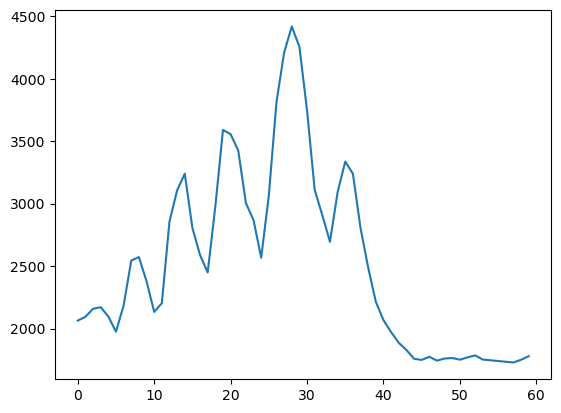

In [39]:
plt.plot(new_df['ppf020_xy113_0'])

In [37]:
new_df['ppf020_xy113_0'].interpolate(inplace=True)

In [40]:
new_df.columns[new_df.isna().any()]

Index([], dtype='object')

In [41]:
new_df.to_csv('./valid_signals_interpolated_ppf020')